In [2]:
import pandas as pd
import pickle as pkl
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import json

In [3]:
# get the training and validation data
with open('../data/processed/df_tabular_train.pkl', 'rb') as f:
    df_train = pkl.load(f)

with open('../data/processed/df_tabular_validate.pkl', 'rb') as f:
    df_validate = pkl.load(f)

In [4]:
# seperate into features and target
X_train = df_train.drop(columns=['hourly_usage_kwh'])
X_validate = df_validate.drop(columns=['hourly_usage_kwh'])

y_train = df_train['hourly_usage_kwh']
y_validate = df_validate['hourly_usage_kwh']

In [ ]:
# create pipelines with linReg models (so same scaling applied during evaluation and inference)
pipeline_OLS = Pipeline([('scale', StandardScaler()), ('rgr', LinearRegression())])
pipeline_Ridge = Pipeline([('scale', StandardScaler()), ('rgr', Ridge())])
pipeline_Lasso = Pipeline([('scale', StandardScaler()), ('rgr', Lasso())])

In [ ]:
# fit the models
pipeline_OLS.fit(X_train, y_train)
pipeline_Ridge.fit(X_train, y_train)
pipeline_Lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scale', ...), ('rgr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [43]:
# quick evaluation

with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    df_test = pkl.load(f)

X_test = df_test.drop(columns=['hourly_usage_kwh'])
y_test = df_test['hourly_usage_kwh']

In [44]:
# mean usages per client IN THE TEST DATA
mean_usages = df_test.groupby(level='client_id')['hourly_usage_kwh'].mean()

In [45]:
# get predictions
y_pred_OLS = pipeline_OLS.predict(X_test)
y_pred_Lasso = pipeline_Lasso.predict(X_test)
y_pred_Ridge = pipeline_Ridge.predict(X_test)

In [46]:
# create frame from client ids and predictions
df_preds = pd.DataFrame(index=df_test.index, data={'y_pred_OLS': y_pred_OLS,
                                                   'y_pred_Lasso': y_pred_Lasso,
                                                   'y_pred_Ridge': y_pred_Ridge,
                                                      'y_true': y_test})

In [47]:
df_preds.tail()

y_pred_OLS  y_pred_Lasso  y_pred_Ridge  \
client_id datetime                                                        
370       2014-12-31 20:00:00  10268.213583  10534.492433  10281.095900   
          2014-12-31 21:00:00   9242.418091   9491.968836   9252.688340   
          2014-12-31 22:00:00   9012.399516   9130.746253   9021.043580   
          2014-12-31 23:00:00   9046.817795   9113.940287   9051.910235   
          2015-01-01 00:00:00   8331.112795   8451.491207   8342.276657   

                                    y_true  
client_id datetime                          
370       2014-12-31 20:00:00  8729.729730  
          2014-12-31 21:00:00  8216.216216  
          2014-12-31 22:00:00  8297.297297  
          2014-12-31 23:00:00  7527.027027  
          2015-01-01 00:00:00  6810.810811

In [48]:
# for each client compute the rmse
rmse_per_client_OLS = df_preds.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred_OLS']))
rmse_per_client_Lasso = df_preds.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred_Lasso']))
rmse_per_client_Ridge = df_preds.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred_Ridge']))

In [49]:
# get the mean normalised
nrmse_per_client_OLS = rmse_per_client_OLS/mean_usages
nrmse_per_client_Lasso = rmse_per_client_Lasso/mean_usages
nrmse_per_client_Ridge = rmse_per_client_Ridge/mean_usages

In [50]:
summary_dict_OLS = {
                'mean': nrmse_per_client_OLS.mean(),
                'std': nrmse_per_client_OLS.std(),
                'max': nrmse_per_client_OLS.max(),
                'min': nrmse_per_client_OLS.min(),
                }

summary_dict_Lasso = {
                'mean': nrmse_per_client_Lasso.mean(),
                'std': nrmse_per_client_Lasso.std(),
                'max': nrmse_per_client_Lasso.max(),
                'min': nrmse_per_client_Lasso.min(),
                }

summary_dict_Ridge = {
                'mean': nrmse_per_client_Ridge.mean(),
                'std': nrmse_per_client_Ridge.std(),
                'max': nrmse_per_client_Ridge.max(),
                'min': nrmse_per_client_Ridge.min(),
                }

In [51]:
print(summary_dict_OLS['mean'])
print(summary_dict_Lasso['mean'])
print(summary_dict_Ridge['mean'])

0.18631280292229951
0.23523361821641697
0.18703281404854288


In [52]:
lasso_coeffs = pipeline_Lasso.steps[1][-1].coef_
ridge_coeffs = pipeline_Ridge.steps[1][-1].coef_
OLS_coeffs = pipeline_OLS.steps[1][-1].coef_

feature_names = X_train.columns

df_coeffs = pd.DataFrame(data={'feature': feature_names,
                                'Lasso': lasso_coeffs, 
                                'Ridge': ridge_coeffs, 
                               'OLS': OLS_coeffs})

df_coeffs.head(50)

,feature,Lasso,Ridge,OLS
0,hour_sin,0.430031,-1.225517,-1.222261
1,hour_cos,-15.437758,-10.344912,-10.257470
2,day_sin,0.000000,0.793610,0.787183
3,day_cos,0.000000,0.552197,0.550849
4,month_sin,0.000000,0.475350,0.471279
5,month_cos,-0.000000,-0.463073,-0.463059
6,1hr_lag,911.776815,1013.938362,1023.070673
7,lag_2hr,-0.000000,-111.585547,-119.311854
8,lag_6hr,-30.386183,-89.892963,-89.428673
9,lag_1dy,91.825760,76.390565,75.616153


In [53]:
# log the results 

# and log these, along with dataframe of predicitons

with open('../logs/linReg/nrmse_summary_stats_OLS.json', 'w') as f:
    json.dump(summary_dict_OLS, f, indent=4)

with open('../logs/linReg/nrmse_summary_stats_Lasso.json', 'w') as f:
    json.dump(summary_dict_Lasso, f, indent=4)

with open('../logs/linReg/nrmse_summary_stats_Ridge.json', 'w') as f:
    json.dump(summary_dict_Ridge, f, indent=4)

with open('../logs/linReg/nrmse_per_client_OLS.json', 'w') as f:
    json.dump(nrmse_per_client_OLS.to_list(), f, indent=4)

with open('../logs/linReg/nrmse_per_client_Lasso.json', 'w') as f:
    json.dump(nrmse_per_client_Lasso.to_list(), f, indent=4)

with open('../logs/linReg/nrmse_per_client_Ridge.json', 'w') as f:
    json.dump(nrmse_per_client_Ridge.to_list(), f, indent=4)

# save the XGB model used
with open('../models/OLS.pkl', 'wb') as f:
    pkl.dump(pipeline_OLS, f)

with open('../models/Lasso.pkl', 'wb') as f:
    pkl.dump(pipeline_Lasso, f)

with open('../models/Ridge.pkl', 'wb') as f:
    pkl.dump(pipeline_Ridge, f)

# save predictions and labels for further evaluation (also gives client ids used)
df_preds.to_csv('../data/processed/linRegModels_preds_labels.csv')

In [54]:
# now for simple plot check
import matplotlib.pyplot as plt

client = 15

df_preds_filtered = df_preds[df_preds.index.get_level_values('client_id') == client].iloc[0:128*4]
datetimes = pd.to_datetime(df_preds_filtered.index.get_level_values('datetime'))
preds_OLS = df_preds_filtered['y_pred_OLS']
preds_Lasso = df_preds_filtered['y_pred_Lasso']
preds_Ridge = df_preds_filtered['y_pred_Ridge']
labels = df_preds_filtered['y_true']

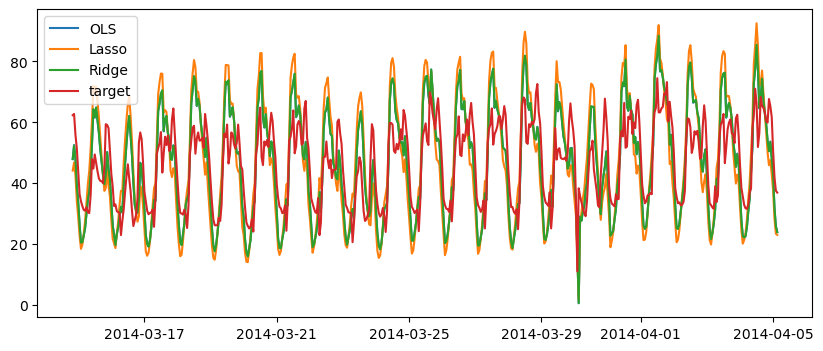

In [55]:
plt.figure(figsize=(10, 4))
plt.plot(datetimes, preds_OLS, label='OLS')
plt.plot(datetimes, preds_Lasso, label='Lasso')
plt.plot(datetimes, preds_Ridge, label='Ridge')
plt.plot(datetimes, labels, label='target')
plt.legend()
plt.show()